# 01 - The dataset before any windowing

The source is the `prom_slurm_joined` table from the SURF Lisa academic HPC cluster
(Chu et al., ICPADS 2024, arXiv:2409.08949): Prometheus node telemetry joined to Slurm
job metadata, one row per `(node, timestamp)` per job.

The notebook is in two parts, and they answer different kinds of question.

**Part 1 - The dataset as it is.** Properties of the raw table: how many jobs and
snapshots exist, how they are distributed across end states, how long jobs run, how
regular the telemetry is, what hardware and queues they run on, and which columns carry
information. Nothing here depends on any modelling choice, and no window, horizon or
label parameter appears.

**Part 2 - Checks prompted by a downstream result.** Four questions that are only worth
asking because something further along the pipeline came out a particular way. Each one
states what is being tested and what prompted it before any code runs, so the
motivation is auditable rather than assumed.

Outputs: `data/jobs.parquet` (one row per job, used by every later notebook),
`data/raw_census.parquet` (cached scan) and `data/facts_01.json`. Figures go to
`figures/`.

In [1]:
# --- Setup ------------------------------------------------------------------
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW    = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
HWINFO = ROOT / "dataset" / "node_hardware_info.parquet"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# The five Slurm end states. Four of them count as failures; CANCELLED is a user
# pressing stop and is excluded from the population in step 2.
# "OOM" always denotes the OUT_OF_MEMORY *job state*, never a machine that ran out of RAM.
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})

def save(fig, name):
    """Write a figure into figures/ and return it so the cell still displays it."""
    fig.savefig(FIGS / name, bbox_inches="tight")
    return fig

print("dataset:", RAW, "|", "found" if RAW.exists() else "MISSING")

dataset: D:\_fcall\UNIFEI\tcc\hpc_workload\dataset\prom_slurm_joined\prom_slurm_joined.parquet | found


# Part 1 - The dataset as it is

## 1. Census of the whole table

The table is ~10 GB in 200 parts, so it is never loaded. Each part is grouped in Arrow
down to one row per `(slurm_id, state, gpu_node)` and only those summaries are
concatenated: the whole table is read in about 15 seconds using a few hundred MB.

In [2]:
census_path = DATA / "raw_census.parquet"

if census_path.exists():
    census = pd.read_parquet(census_path)
    print("loaded cached census")
else:
    t0 = time.time()
    parts = sorted(RAW.glob("part-*.parquet"))
    chunks = []
    for p in parts:
        tab = pq.read_table(p, columns=["slurm_id", "state", "gpu_node", "timestamp"])
        chunks.append(tab.group_by(["slurm_id", "state", "gpu_node"]).aggregate(
            [("timestamp", "min"), ("timestamp", "max"), ([], "count_all")]))
    census = pa.concat_tables(chunks).to_pandas()
    # A job can be split across parts, so collapse the per-part summaries.
    census = (census.groupby(["slurm_id", "state", "gpu_node"], as_index=False)
                    .agg(first_ts=("timestamp_min", "min"),
                         last_ts=("timestamp_max", "max"),
                         n_snap=("count_all", "sum")))
    census.to_parquet(census_path, index=False)
    print(f"scanned {len(parts)} parts in {time.time() - t0:.0f}s")

# A job must carry exactly one state and one gpu_node flag.
assert census.slurm_id.is_unique, "a slurm_id appeared with two different states"

n_snap_all, n_jobs_all = int(census.n_snap.sum()), len(census)
gpu = census[census.gpu_node == 1]
gpu_nc = gpu[gpu.state != "CANCELLED"]

print(f"TOTAL snapshots         {n_snap_all:>12,}")
print(f"TOTAL jobs              {n_jobs_all:>12,}")
print(f"GPU jobs                {len(gpu):>12,}   ({len(gpu)/n_jobs_all:.1%} of all jobs)")
print(f"GPU jobs, non-CANCELLED {len(gpu_nc):>12,}")
print(f"GPU snapshots           {int(gpu.n_snap.sum()):>12,}")
print()
print("jobs and snapshots by (gpu_node, state):")
print(census.groupby(["gpu_node", "state"]).agg(jobs=("slurm_id", "size"),
                                                snapshots=("n_snap", "sum")).to_string())

loaded cached census


TOTAL snapshots           93,950,875
TOTAL jobs                   293,891
GPU jobs                      27,287   (9.3% of all jobs)
GPU jobs, non-CANCELLED       23,618
GPU snapshots             13,459,188

jobs and snapshots by (gpu_node, state):
                          jobs  snapshots
gpu_node state                           
0        CANCELLED        9592    6196099
         COMPLETED      202874   43195044
         FAILED          37588    4504303
         NODE_FAIL        1426    2260157
         OUT_OF_MEMORY    4499     672292
         TIMEOUT         10625   23663792
1        CANCELLED        3669    2314346
         COMPLETED       17306    6769458
         FAILED           4664     631137
         NODE_FAIL         107      27951
         OUT_OF_MEMORY     130      73016
         TIMEOUT          1411    3643280


## 2. The population 

Two exclusions define the population used from here on.

* **GPU nodes only.** The subject is GPU-node health, and the `nvidia_gpu_*` columns are
  identically zero on the rest of the cluster.
* **Drop `CANCELLED`.** A cancelled job records a user's decision, not a machine's
  condition.

Both are properties of the question being asked, not of any model.

parts containing gpu_node=1 rows: 29 of 200 (indices 171-199)


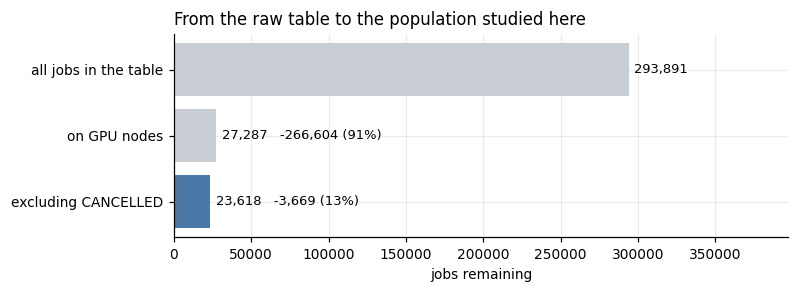

23,618 of 293,891 jobs = 8.0% of the table


In [3]:
# Which parts hold GPU rows at all? Answered from row-group statistics, no data read.
parts = sorted(RAW.glob("part-*.parquet"))
gpu_parts = [i for i, p in enumerate(parts)
             if pq.ParquetFile(p).metadata.row_group(0).column(
                 pq.ParquetFile(p).schema_arrow.names.index("gpu_node")).statistics.max == 1]
print(f"parts containing gpu_node=1 rows: {len(gpu_parts)} of {len(parts)} "
      f"(indices {min(gpu_parts)}-{max(gpu_parts)})")

steps = [("all jobs in the table", n_jobs_all),
         ("on GPU nodes", len(gpu)),
         ("excluding CANCELLED", len(gpu_nc))]
fig, ax = plt.subplots(figsize=(7.2, 2.4))
vals = [s[1] for s in steps]
bars = ax.barh(range(len(steps)), vals, color=["#c9ced4", "#c9ced4", "#4c78a8"])
ax.set_yticks(range(len(steps)), [s[0] for s in steps]); ax.invert_yaxis()
ax.set_xlabel("jobs remaining")
for i, (b, v) in enumerate(zip(bars, vals)):
    lost = "" if i == 0 else f"   -{vals[i-1]-v:,} ({(vals[i-1]-v)/vals[i-1]:.0%})"
    ax.text(v + n_jobs_all * 0.012, b.get_y() + b.get_height()/2, f"{v:,}{lost}",
            va="center", fontsize=8.5)
ax.set_xlim(0, n_jobs_all * 1.35)
ax.set_title("From the raw table to the population studied here", loc="left")
save(fig, "01_funnel.png"); plt.show()
print(f"{vals[-1]:,} of {n_jobs_all:,} jobs = {vals[-1]/n_jobs_all:.1%} of the table")

## 3. The job table

The key columns for every snapshot in that population are loaded and reduced to one row
per job. Two duration measures are kept and cross-checked:

* `slurm_h` = `end_date - start_date`, the runtime Slurm recorded;
* `tele_h` = `last_ts - first_ts`, the span telemetry actually covers.

In [4]:
KEYS = ["slurm_id", "node", "timestamp", "state", "start_date", "end_date",
        "nodetypes", "numnodes", "numcores"]
t0 = time.time()
tabs = []
for p in parts:
    tab = pq.read_table(p, columns=KEYS + ["gpu_node"])
    tab = tab.filter((pc.field("gpu_node") == 1) & (pc.field("state") != "CANCELLED"))
    if tab.num_rows:
        tabs.append(tab.drop_columns(["gpu_node"]))
snap = pa.concat_tables(tabs).to_pandas()
del tabs; gc.collect()
for c in ("node", "state", "nodetypes"):
    snap[c] = snap[c].astype("category")
snap = snap.sort_values(["slurm_id", "node", "timestamp"], kind="stable", ignore_index=True)
print(f"{len(snap):,} snapshots, {snap.memory_usage(deep=True).sum()/1e6:.0f} MB, "
      f"{time.time()-t0:.0f}s")

11,144,842 snapshots, 435 MB, 24s


In [5]:
g = snap.groupby("slurm_id", observed=True)
jobs = pd.DataFrame({
    "state":      g.state.first(),
    "nodetypes":  g.nodetypes.first(),
    "node":       g.node.first(),          # primary node (a job may span several)
    "numnodes":   g.numnodes.first(),      # nodes Slurm allocated
    "numcores":   g.numcores.first(),
    "start_date": g.start_date.first(),
    "end_date":   g.end_date.first(),
    "first_ts":   g.timestamp.min(),
    "last_ts":    g.timestamp.max(),
    "n_snap":     g.size(),
    "n_nodes_seen": g.node.nunique(),      # nodes that actually reported telemetry
}).reset_index()

jobs["slurm_h"]    = (jobs.end_date - jobs.start_date).dt.total_seconds() / 3600
jobs["tele_h"]     = (jobs.last_ts - jobs.first_ts).dt.total_seconds() / 3600
jobs["is_failure"] = jobs.state.isin(FAILURE_STATES)
jobs["node_hours"] = jobs.slurm_h * jobs.numnodes

T0, T1 = snap.timestamp.min(), snap.timestamp.max()
print(f"{len(jobs):,} jobs | {jobs.node.nunique()} nodes")
print(f"telemetry period: {T0} -> {T1} ({(T1-T0).days} days)")

23,618 jobs | 51 nodes
telemetry period: 2022-08-25 10:27:00 -> 2022-11-01 13:58:00 (68 days)


In [6]:
# --- consistency between the two clocks -------------------------------------
gap_end = (jobs.end_date - jobs.last_ts).dt.total_seconds()
print(f"jobs starting before telemetry begins  : {int((jobs.start_date < T0).sum()):>5}")
print(f"jobs ending after telemetry stops      : {int((jobs.end_date > T1).sum()):>5}")
print(f"median (slurm_h - tele_h)              : "
      f"{((jobs.slurm_h-jobs.tele_h)*60).median():.2f} min   <- one cadence step")
print(f"jobs whose telemetry stops >5 min early: {int((gap_end > 300).sum()):>5} "
      f"({(gap_end > 300).mean():.1%})")
print(f"\nSlurm reports >1 node for {int((jobs.numnodes > 1).sum())} jobs; "
      f"telemetry covers >1 node for {int((jobs.n_nodes_seen > 1).sum())}.")

jobs starting before telemetry begins  :    36
jobs ending after telemetry stops      :     1
median (slurm_h - tele_h)              : 0.47 min   <- one cadence step
jobs whose telemetry stops >5 min early:   211 (0.9%)

Slurm reports >1 node for 152 jobs; telemetry covers >1 node for 123.


## 4. States, counted two ways

The same population as a share of **jobs** and as a share of **snapshots**. The two
differ sharply, because long-running states occupy far more telemetry than their job
count suggests.

                jobs  snapshots job_share snap_share node_hours
state                                                          
COMPLETED      17306    6769458    73.27%     60.74%     58,012
FAILED          4664     631137    19.75%      5.66%      5,343
TIMEOUT         1411    3643280     5.97%     32.69%     31,044
OUT_OF_MEMORY    130      73016     0.55%      0.66%        625
NODE_FAIL        107      27951     0.45%      0.25%        237

failure rate, by job:      26.73%
failure rate, by snapshot: 39.26%


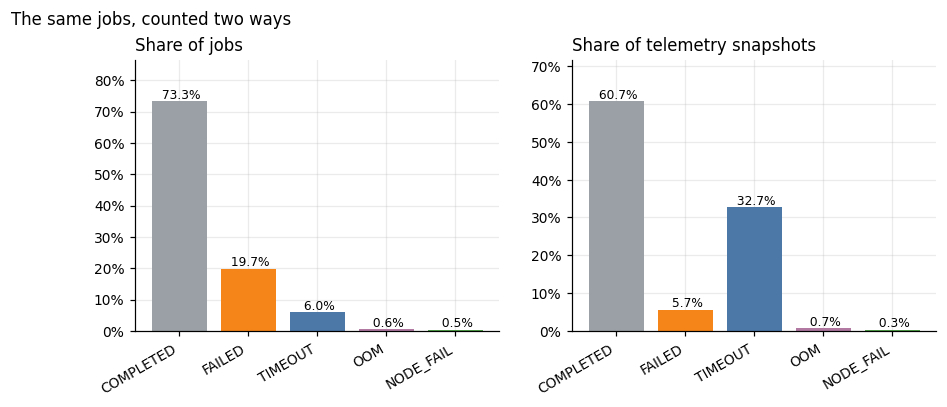

In [7]:
by_state = pd.DataFrame({
    "jobs":      jobs.groupby("state", observed=True).size(),
    "snapshots": jobs.groupby("state", observed=True).n_snap.sum(),
}).reindex(STATES)
by_state["job_share"]  = by_state.jobs / by_state.jobs.sum()
by_state["snap_share"] = by_state.snapshots / by_state.snapshots.sum()
by_state["node_hours"] = jobs.groupby("state", observed=True).node_hours.sum().reindex(STATES)
print(by_state.to_string(formatters={"job_share": "{:.2%}".format,
                                     "snap_share": "{:.2%}".format,
                                     "node_hours": "{:,.0f}".format}))
print(f"\nfailure rate, by job:      {jobs.is_failure.mean():.2%}")
print(f"failure rate, by snapshot: "
      f"{by_state.loc[list(FAILURE_STATES),'snapshots'].sum()/by_state.snapshots.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.2))
for ax, col, title in zip(axes, ["job_share", "snap_share"],
                          ["Share of jobs", "Share of telemetry snapshots"]):
    v = by_state[col]
    ax.bar(range(len(v)), v.values, color=[COLOR[s] for s in v.index])
    ax.set_xticks(range(len(v)), [s.replace("OUT_OF_MEMORY", "OOM") for s in v.index],
                  rotation=30, ha="right")
    ax.set_title(title, loc="left")
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    for i, val in enumerate(v.values):
        ax.text(i, val, f" {val:.1%}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, max(v.values) * 1.18)
fig.suptitle("The same jobs, counted two ways", x=0.005, ha="left", y=1.02)
save(fig, "02_labels.png"); plt.show()

## 5. How long jobs run

`FAILED` is the most numerous failure state and the shortest-lived; `TIMEOUT` is the
opposite. The spread across states covers four orders of magnitude, which is the single
most consequential property of this dataset.

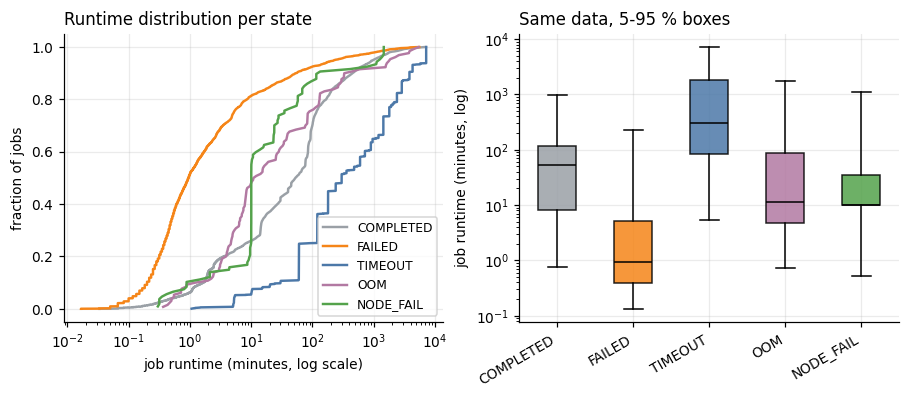

                jobs median_min p90_min
state                                  
COMPLETED      17306       52.7   449.5
FAILED          4664        1.0    53.5
TIMEOUT         1411      300.2  3840.5
OUT_OF_MEMORY    130       11.5   344.6
NODE_FAIL        107       10.1   123.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.4))

ax = axes[0]
for s in STATES:
    d = np.sort(jobs.loc[jobs.state == s, "slurm_h"].to_numpy() * 60)
    d = d[d > 0]
    ax.plot(d, np.arange(1, len(d) + 1) / len(d), color=COLOR[s], lw=1.6,
            label=s.replace("OUT_OF_MEMORY", "OOM"))
ax.set_xscale("log"); ax.set_xlabel("job runtime (minutes, log scale)")
ax.set_ylabel("fraction of jobs"); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Runtime distribution per state", loc="left")

ax = axes[1]
data = [jobs.loc[jobs.state == s, "slurm_h"].to_numpy() * 60 for s in STATES]
bp = ax.boxplot(data, vert=True, whis=(5, 95), showfliers=False, patch_artist=True,
                medianprops=dict(color="black"))
for patch, s in zip(bp["boxes"], STATES):
    patch.set_facecolor(COLOR[s]); patch.set_alpha(0.85)
ax.set_yscale("log")
ax.set_xticks(range(1, len(STATES) + 1),
              [s.replace("OUT_OF_MEMORY", "OOM") for s in STATES], rotation=30, ha="right")
ax.set_ylabel("job runtime (minutes, log)")
ax.set_title("Same data, 5-95 % boxes", loc="left")
save(fig, "03_duration.png"); plt.show()

print(jobs.groupby("state", observed=True).agg(
    jobs=("slurm_id", "size"),
    median_min=("slurm_h", lambda s: s.median() * 60),
    p90_min=("slurm_h", lambda s: s.quantile(.9) * 60)).reindex(STATES).to_string(
        formatters={"median_min": "{:.1f}".format, "p90_min": "{:.1f}".format}))

## 6. Telemetry cadence and gaps

Measured inside each `(job, node)` series rather than globally, because that is the
sequence any time-ordered analysis is cut from.

intervals measured: 11,121,070
median 30.0s | mean 30.3s
exactly 30s: 99.9942%
longer than twice the cadence: 610 (0.00549%)
largest gap: 2.02 h


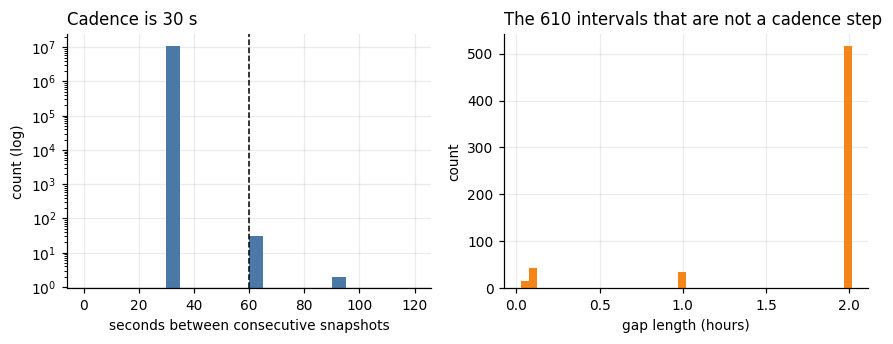


most common large gap: {2.01: 483, 0.08: 37, 1.01: 34}
One value dominating the large gaps is the signature of a single cluster-wide
monitoring outage rather than per-node flakiness.


In [9]:
sid = snap.slurm_id.astype(np.int64).to_numpy() * 1000 + snap.node.cat.codes.to_numpy()
ts_ns = snap.timestamp.astype("int64").to_numpy()
dt = np.diff(ts_ns)[sid[1:] == sid[:-1]] / 1e9
CADENCE_S = float(np.median(dt))

print(f"intervals measured: {len(dt):,}")
print(f"median {CADENCE_S:.1f}s | mean {dt.mean():.1f}s")
print(f"exactly {CADENCE_S:.0f}s: {(dt == CADENCE_S).mean():.4%}")
print(f"longer than twice the cadence: {int((dt > 2*CADENCE_S).sum()):,} "
      f"({(dt > 2*CADENCE_S).mean():.5%})")
print(f"largest gap: {dt.max()/3600:.2f} h")

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0))
axes[0].hist(dt[dt <= 120], bins=np.arange(0, 125, 5), color="#4c78a8")
axes[0].set_yscale("log"); axes[0].set_xlabel("seconds between consecutive snapshots")
axes[0].set_ylabel("count (log)"); axes[0].axvline(2*CADENCE_S, color="k", ls="--", lw=1)
axes[0].set_title(f"Cadence is {CADENCE_S:.0f} s", loc="left")

big = dt[dt > 2*CADENCE_S] / 3600
axes[1].hist(big, bins=40, color="#f58518")
axes[1].set_xlabel("gap length (hours)"); axes[1].set_ylabel("count")
axes[1].set_title(f"The {len(big):,} intervals that are not a cadence step", loc="left")
save(fig, "04_cadence.png"); plt.show()

print(f"\nmost common large gap: {pd.Series(big.round(2)).value_counts().head(3).to_dict()}")
print("One value dominating the large gaps is the signature of a single cluster-wide")
print("monitoring outage rather than per-node flakiness.")

## 7. Hardware, queues and nodes

`node_hardware_info.parquet` gives each node's GPU model; `nodetypes` gives the queue
the job was submitted to.

In [10]:
hw = pd.read_parquet(HWINFO)[["node", "gpu_model", "gpu_count",
                              "gpu_memory_bytes_per_card", "cpu_model"]]
jh = jobs.merge(hw, on="node", how="left")
assert jh.gpu_model.notna().all(), "a node is missing from node_hardware_info"

print("by GPU model:")
print(jh.groupby("gpu_model", observed=True).agg(
    nodes=("node", "nunique"), jobs=("slurm_id", "size"),
    failure_rate=("is_failure", "mean"),
    median_runtime_min=("slurm_h", lambda s: s.median() * 60)).to_string(
        formatters={"failure_rate": "{:.1%}".format, "median_runtime_min": "{:.1f}".format}))

print("\nby queue:")
qs = jh.groupby("nodetypes", observed=True).agg(
    jobs=("slurm_id", "size"), failure_rate=("is_failure", "mean"),
    median_runtime_min=("slurm_h", lambda s: s.median() * 60))
for s in FAILURE_STATES:
    qs[s] = jh.assign(x=jh.state == s).groupby("nodetypes", observed=True).x.mean()
print(qs.sort_values("jobs", ascending=False).to_string(
    formatters={c: "{:.1%}".format for c in ["failure_rate"] + list(FAILURE_STATES)}
    | {"median_runtime_min": "{:.1f}".format}))

by GPU model:
                            nodes   jobs failure_rate median_runtime_min
gpu_model                                                               
NVIDIA_GeForce_GTX_1080_Ti     20  13311        25.1%               23.5
NVIDIA_TITAN_RTX               31  10307        28.8%               40.1

by queue:
                             jobs failure_rate median_runtime_min FAILED TIMEOUT OUT_OF_MEMORY NODE_FAIL
nodetypes                                                                                               
gpu_shared                  10890        17.2%               45.0  12.5%    4.0%          0.2%      0.4%
gpu_titanrtx_shared          8280        29.5%               52.4  20.7%    7.9%          0.5%      0.4%
gpu_shared_course            1904        64.8%                2.7  59.5%    3.0%          1.8%      0.5%
gpu_titanrtx                 1440        21.0%               40.1  15.6%    4.4%          0.3%      0.7%
gpu                           404        35.9%       

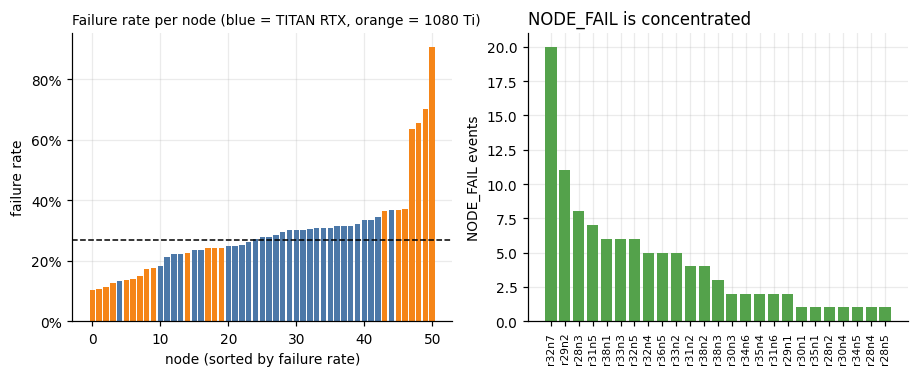

failure rate per node: min 10.2%, median 27.8%, max 90.7%
NODE_FAIL: 107 events on 25 of 51 nodes; worst node r32n7 has 20


In [11]:
per_node = jh.groupby("node", observed=True).agg(
    jobs=("slurm_id", "size"), failure_rate=("is_failure", "mean"),
    gpu_model=("gpu_model", "first")).sort_values("failure_rate")
nf = jh[jh.state == "NODE_FAIL"].node.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.4))
ax = axes[0]
ax.bar(range(len(per_node)), per_node.failure_rate,
       color=["#4c78a8" if m == "NVIDIA_TITAN_RTX" else "#f58518"
              for m in per_node.gpu_model])
ax.axhline(jobs.is_failure.mean(), color="k", ls="--", lw=1)
ax.set_xlabel("node (sorted by failure rate)"); ax.set_ylabel("failure rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Failure rate per node (blue = TITAN RTX, orange = 1080 Ti)", loc="left",
             fontsize=9)

ax = axes[1]
ax.bar(range(len(nf)), nf.values, color="#54a24b")
ax.set_xticks(range(len(nf)), nf.index, rotation=90, fontsize=7)
ax.set_ylabel("NODE_FAIL events"); ax.set_title("NODE_FAIL is concentrated", loc="left")
save(fig, "07_hardware.png"); plt.show()

print(f"failure rate per node: min {per_node.failure_rate.min():.1%}, "
      f"median {per_node.failure_rate.median():.1%}, max {per_node.failure_rate.max():.1%}")
print(f"NODE_FAIL: {int(nf.sum())} events on {len(nf)} of {jobs.node.nunique()} nodes; "
      f"worst node {nf.index[0]} has {int(nf.iloc[0])}")

The queue separates the population more sharply than the hardware does.
`gpu_shared_jupyter` fails most of the time and almost entirely by `TIMEOUT` -
interactive notebook sessions left open until they hit the walltime. `gpu_shared_course`
fails largely by `FAILED`, which is what a teaching queue of student jobs looks like.
`NODE_FAIL`, the one state that unambiguously means the machine broke, is concentrated
on a small number of nodes.

## 8. Column health

The table has 100 columns. A column that is constant, or takes only a handful of distinct
values, cannot contribute to any aggregate feature, so it is worth identifying before
any metric shortlist is fixed.

In [12]:
CANDIDATES = [
    "nvidia_gpu_temperature_celsius_mean", "nvidia_gpu_temperature_celsius_max",
    "nvidia_gpu_power_usage_milliwatts_mean", "nvidia_gpu_duty_cycle_mean",
    "nvidia_gpu_memory_used_bytes_sum", "nvidia_gpu_fanspeed_percent_mean",
    "node_memory_MemFree_bytes", "node_memory_Active_bytes", "node_memory_Dirty_bytes",
    "node_load1", "node_load15", "node_procs_running", "node_procs_blocked",
    "node_power_usage", "node_hwmon_temp_celsius_max", "node_thermal_zone_temp_max",
    "node_disk_written_bytes_total_sum", "node_network_receive_bytes_total_sum",
    "node_netstat_Tcp_InErrs", "node_netstat_Tcp_RetransSegs", "node_context_switches_total",
    "node_filesystem_avail_bytes_sum", "node_disk_io_now_sum", "node_forks_total",
]
# One part is enough to spot a dead column; part 185 is pure gpu_node=1.
probe = pq.read_table(parts[185], columns=CANDIDATES + ["gpu_node", "state"])
probe = probe.filter((pc.field("gpu_node") == 1)
                     & (pc.field("state") != "CANCELLED")).to_pandas()

health = pd.DataFrame({
    "null_%": probe[CANDIDATES].isna().mean() * 100,
    "distinct": probe[CANDIDATES].nunique(),
    "std": probe[CANDIDATES].std(),
}).sort_values("distinct")
health["verdict"] = np.where(health.distinct <= 1, "CONSTANT - unusable",
                     np.where(health.distinct < 20, "very coarse", "ok"))
print(f"probe rows: {len(probe):,}\n")
print(health.to_string(formatters={"null_%": "{:.2f}".format, "std": "{:.3g}".format}))

probe rows: 447,265

                                       null_%  distinct      std              verdict
node_disk_io_now_sum                     0.00         1        0  CONSTANT - unusable
node_netstat_Tcp_InErrs                  0.00         4    0.778          very coarse
node_hwmon_temp_celsius_max              0.00         9     1.08          very coarse
node_thermal_zone_temp_max               0.00        10     1.09          very coarse
node_procs_blocked                       0.00        23    0.594                   ok
node_power_usage                         0.00        47      227                   ok
node_procs_running                       0.00        50     5.78                   ok
nvidia_gpu_temperature_celsius_max       0.00        55     10.1                   ok
nvidia_gpu_fanspeed_percent_mean         0.00       171     9.68                   ok
nvidia_gpu_temperature_celsius_mean      0.00       178     9.69                   ok
nvidia_gpu_duty_cycle_mean       

No column is fully null, but several are very coarse: `node_power_usage` and the hwmon
temperatures take a few dozen distinct values across millions of snapshots, so a
within-window standard deviation over them will frequently be exactly zero.

# Part 2 - Checks prompted by a downstream result

The four questions below are not general descriptions of the data. Each one exists
because a later stage of the work produced a specific result, and each is stated in the
same form: **what is being tested**, and **what prompted it**.

They need three parameters from the modelling pipeline, which appear here only as
reference marks and are not used anywhere in Part 1.

In [13]:
# --- parameters of the downstream pipeline, needed only to ask these questions ---
WINDOW     = 40     # snapshots per feature row -> 20 minutes at the measured cadence
HORIZON_H  = 2.0    # a snapshot is labelled positive within 2 h of a failing job's end
TRAIN_FRAC = 0.8    # temporal split: the earliest 80 % of jobs by end_date are train
print(f"window {WINDOW} snapshots = {WINDOW*CADENCE_S/60:.0f} min | "
      f"horizon {HORIZON_H:.0f} h | train fraction {TRAIN_FRAC:.0%}")

window 40 snapshots = 20 min | horizon 2 h | train fraction 80%


## 9. Can a failing job be observed at all?

**Testing** the runtime of failing jobs against the amount of history one feature row
needs (`WINDOW` = 40 consecutive snapshots = 20 minutes).

**Prompted by** the modelling results: recall stayed low across every model family,
horizon and feature set tried, while precision at the top of the ranking stayed high.
That pattern is what a coverage limit looks like rather than an accuracy limit, so the
share of failures that can produce even one feature row is worth measuring directly.

This is a ceiling on recall that no algorithm can lift, because it is set before any
model exists.

In [14]:
short = jobs[jobs.is_failure].groupby("state", observed=True).apply(
    lambda d: pd.Series({
        "failing jobs": len(d),
        "shorter than one window": (d.n_snap < WINDOW).mean(),
        "shorter than the horizon": (d.slurm_h < HORIZON_H).mean(),
    }), include_groups=False)
print(short.to_string(formatters={"shorter than one window": "{:.1%}".format,
                                  "shorter than the horizon": "{:.1%}".format}))
f = jobs[jobs.is_failure]
print(f"\nall failing jobs shorter than one window : "
      f"{(f.n_snap < WINDOW).mean():.1%}")
print(f"all failing jobs shorter than the {HORIZON_H:.0f} h horizon: "
      f"{(f.slurm_h < HORIZON_H).mean():.1%} (Slurm runtime) / "
      f"{(f.tele_h < HORIZON_H).mean():.1%} (telemetry span)")

               failing jobs shorter than one window shorter than the horizon
state                                                                       
FAILED               4664.0                   84.7%                    92.9%
NODE_FAIL             107.0                   65.4%                    89.7%
OUT_OF_MEMORY         130.0                   56.2%                    76.9%
TIMEOUT              1411.0                    8.5%                    25.1%

all failing jobs shorter than one window : 66.8%
all failing jobs shorter than the 2 h horizon: 77.3% (Slurm runtime) / 78.7% (telemetry span)


`FAILED`, the most common failure by count, has a median runtime around one minute and
the large majority never produce a complete window. `TIMEOUT` is the opposite. Whatever
a model scores later, it can only score it on the jobs that survive this table.

## 10. Do concurrent jobs receive identical telemetry?

**Testing** how often one `(node, timestamp)` telemetry row is attached to several jobs,
and how often those jobs disagree about the label.

**Prompted by** the modelling results: models on this feature set plateaued near three
times the random baseline across architectures, feature sets and tuning budgets. A
plateau insensitive to the model is the signature of a target that the features do not
determine, so the first thing to check is whether identical feature rows carry different
labels.

Most queues here are **shared** (`gpu_shared`, `gpu_titanrtx_shared`, ...): several jobs
run on one physical node at once. Telemetry is collected **per node**, and the join
attaches the same row to every job running there.

In [15]:
dupe = snap.duplicated(subset=["node", "timestamp"], keep=False)
grp = snap.groupby(["node", "timestamp"], observed=True).slurm_id.nunique()

print(f"snapshots sharing their (node, timestamp) with another job: "
      f"{dupe.mean():.1%}  ({int(dupe.sum()):,})")
print(f"concurrent jobs per node-snapshot: mean {grp.mean():.2f}, max {int(grp.max())}")
snap["co_tenanted"] = dupe.to_numpy()
print("\nco-tenancy by queue:")
print(snap.groupby("nodetypes", observed=True).co_tenanted.agg(["mean", "size"])
          .sort_values("size", ascending=False).to_string(
              formatters={"mean": "{:.1%}".format, "size": "{:,}".format}))

snapshots sharing their (node, timestamp) with another job: 78.4%  (8,740,208)
concurrent jobs per node-snapshot: mean 2.07, max 5

co-tenancy by queue:


                            mean      size
nodetypes                                 
gpu_titanrtx_shared        87.0% 6,018,015
gpu_shared                 87.1% 3,484,502
gpu_titanrtx                0.0%   741,595
gpu                         0.0%   305,424
gpu_shared_course          78.4%   263,576
fat_soil_shared            81.9%   251,765
gpu_titanrtx_shared_course 83.3%    58,442
gpu_shared_jupyter         46.3%    21,523


In [16]:
# Label a snapshot positive when its job ends in a failure state within HORIZON_H.
ttf = (snap.end_date - snap.timestamp).dt.total_seconds().to_numpy()
pos = (snap.state.isin(FAILURE_STATES).to_numpy()
       & (ttf >= 0) & (ttf <= HORIZON_H * 3600)).astype(np.int32)
snap["pos"] = pos
n_pos = int(pos.sum())

g2 = snap.groupby(["node", "timestamp"], observed=True).pos
n_in_group, n_pos_in_group = g2.size().to_numpy(), g2.sum().to_numpy()
co = n_in_group > 1
contradictory = co & (n_pos_in_group > 0) & (n_pos_in_group < n_in_group)
# An oracle forced to give one answer per identical row loses the minority side.
floor = int(np.minimum(n_pos_in_group, n_in_group - n_pos_in_group).sum())

print(f"snapshot positive rate: {pos.mean():.4f}  ({n_pos:,} positives)")
print(f"node-snapshots: {len(n_in_group):,}, of which co-tenanted {co.mean():.1%}")
print(f"co-tenanted node-snapshots with CONTRADICTORY labels: "
      f"{contradictory.sum()/co.sum():.2%} of co-tenanted")
print(f"\npositive snapshots sharing their row with a non-failing job: "
      f"{int(n_pos_in_group[contradictory].sum()):,} / {n_pos:,} "
      f"({n_pos_in_group[contradictory].sum()/n_pos:.1%})")
print(f"snapshots an ORACLE must get wrong using node-level features alone: "
      f"{floor:,} ({floor/n_pos:.1%} of all positives)")
print(f"\n=> ceiling on recall from node-level telemetry: about {1-floor/n_pos:.0%}")

snapshot positive rate: 0.0382  (425,974 positives)
node-snapshots: 5,392,404, of which co-tenanted 55.4%
co-tenanted node-snapshots with CONTRADICTORY labels: 7.03% of co-tenanted

positive snapshots sharing their row with a non-failing job: 241,303 / 425,974 (56.6%)
snapshots an ORACLE must get wrong using node-level features alone: 220,269 (51.7% of all positives)

=> ceiling on recall from node-level telemetry: about 48%


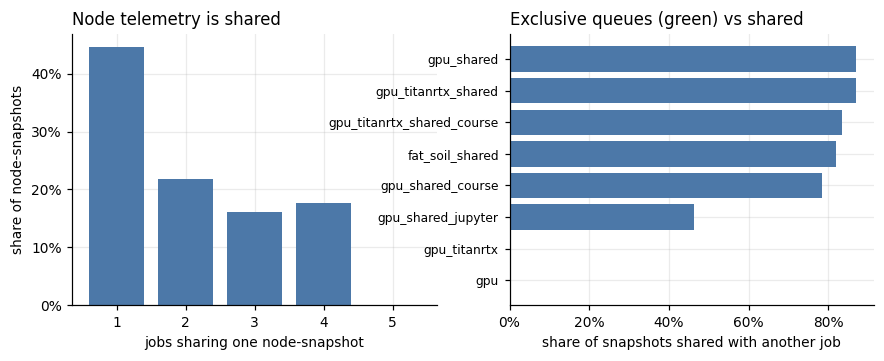

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.2))
ax = axes[0]
vc = grp.value_counts().sort_index()
ax.bar(vc.index, vc.values / vc.sum(), color="#4c78a8")
ax.set_xlabel("jobs sharing one node-snapshot"); ax.set_ylabel("share of node-snapshots")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Node telemetry is shared", loc="left")

ax = axes[1]
q = snap.groupby("nodetypes", observed=True).co_tenanted.mean().sort_values()
ax.barh(range(len(q)), q.values,
        color=["#4c78a8" if v > 0 else "#54a24b" for v in q.values])
ax.set_yticks(range(len(q)), q.index, fontsize=8)
ax.set_xlabel("share of snapshots shared with another job")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Exclusive queues (green) vs shared", loc="left")
save(fig, "05_co_tenancy.png"); plt.show()

Two queues (`gpu` and `gpu_titanrtx`) are exclusive - one job per node - and show 0 %
co-tenancy. Everything else is shared, and roughly half of all positive snapshots sit on
a row that also serves a job which does not fail. Part of the observed plateau is
therefore not a modelling failure: the label is underdetermined by the features. The
exclusive queues are the subset on which the question is well posed.

## 11. Is `TIMEOUT` a property of the node or of the user?

**Testing** the runtimes of `TIMEOUT` jobs against those of `COMPLETED` jobs, for
clustering on whole hours.

**Prompted by** the per-state modelling results: `TIMEOUT` accounted for most of the
measured performance, so what the state actually represents determines how any headline
score should be read. If `TIMEOUT` means "the job reached the limit its user requested",
its runtimes should pile up on values a person types - 1 h, 2 h, 24 h, 120 h - while
`COMPLETED` runtimes should be spread continuously.

There is no requested-walltime column in this dataset, so the hypothesis is tested
indirectly. One trap: very short jobs sit near zero, which is itself a whole number of
hours, so the test is restricted to jobs that ran at least ten minutes.

jobs at least 10 minutes long: 15,167

state               n   within 60 s of a round hour
COMPLETED       12810                         1.9%
FAILED            873                         2.2%
TIMEOUT          1335                        92.6%
OUT_OF_MEMORY      68                         0.0%
NODE_FAIL          81                         0.0%

most common TIMEOUT runtimes (hours, rounded):
slurm_h
1.0      198
2.0      157
3.0      120
24.0     100
120.0     88
0.1       67
48.0      62
30.0      50


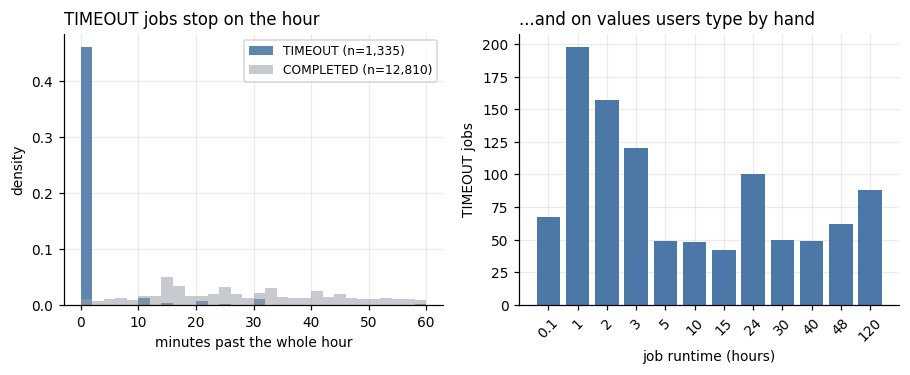

In [18]:
def round_hour_share(h, tol_s=60):
    """Share of runtimes within tol_s of a whole number of hours."""
    off = (h * 3600) % 3600
    return float(((off < tol_s) | (off > 3600 - tol_s)).mean())

long_enough = jobs[jobs.slurm_h >= 1/6]           # at least 10 minutes
print(f"jobs at least 10 minutes long: {len(long_enough):,}\n")
print(f"{'state':<14}{'n':>7}{'within 60 s of a round hour':>30}")
for s in STATES:
    h = long_enough.loc[long_enough.state == s, "slurm_h"]
    if len(h):
        print(f"{s:<14}{len(h):>7}{round_hour_share(h):>29.1%}")

tmo = jobs[jobs.state == "TIMEOUT"]
print(f"\nmost common TIMEOUT runtimes (hours, rounded):")
print(tmo.slurm_h.round(1).value_counts().head(8).to_string())

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.2))
ax = axes[0]
for s, alpha in (("TIMEOUT", 0.9), ("COMPLETED", 0.55)):
    h = long_enough.loc[long_enough.state == s, "slurm_h"]
    ax.hist(((h * 3600) % 3600) / 60, bins=np.arange(0, 61, 2), density=True, alpha=alpha,
            color=COLOR[s], label=f"{s} (n={len(h):,})")
ax.set_xlabel("minutes past the whole hour"); ax.set_ylabel("density")
ax.legend(fontsize=8); ax.set_title("TIMEOUT jobs stop on the hour", loc="left")

ax = axes[1]
vc = tmo.slurm_h.round(1).value_counts().head(12).sort_index()
ax.bar(range(len(vc)), vc.values, color=COLOR["TIMEOUT"])
ax.set_xticks(range(len(vc)), [f"{v:g}" for v in vc.index], rotation=45)
ax.set_xlabel("job runtime (hours)"); ax.set_ylabel("TIMEOUT jobs")
ax.set_title("...and on values users type by hand", loc="left")
save(fig, "08_timeout_walltime.png"); plt.show()

`TIMEOUT` runtimes cluster on whole hours far more than `COMPLETED` runtimes do, and the
most common values are exactly those a person types into a submission script. `TIMEOUT`
is therefore predominantly a user under-estimating the walltime they need, not a node
becoming unhealthy. It remains worth predicting - a job about to be killed at its limit
is worth warning about - but it is a different problem from node health, and pooling it
with `FAILED`, `OUT_OF_MEMORY` and `NODE_FAIL` into one "failure" class mixes two
unrelated phenomena.

## 12. Does the failure rate move over time?

**Testing** the weekly failure rate across the monitored period for non-stationarity.

**Prompted by** a validation result: shuffled k-fold cross-validation on this dataset
reported scores several times higher than a split taken by time. A shuffled split places
jobs from the same week on both sides of the fold boundary, so the gap is evidence of
non-stationarity, and its size can be measured directly.

The split assigned here - the earliest 80 % of jobs by `end_date` - is the one every
later notebook uses.

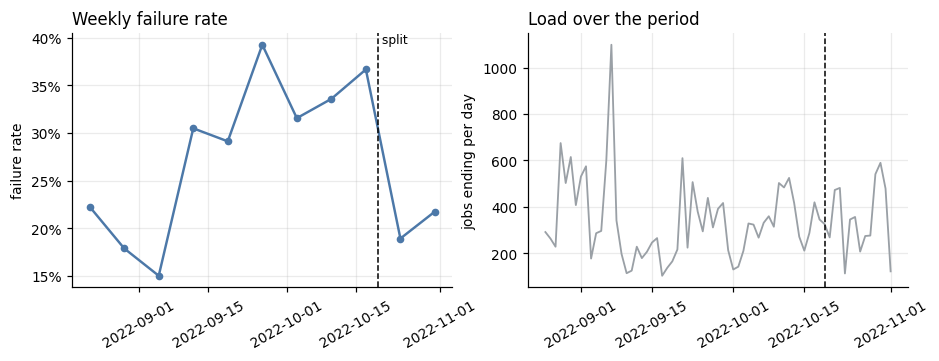

weekly failure rate: min 15.0%, max 39.3%, ratio 2.6x

split time (earliest 80% of jobs by end_date): 2022-10-19 11:50:16
train 18,894 | test 4,724
23,618 jobs -> data/jobs.parquet


In [19]:
wk = (jobs.assign(week=jobs.end_date.dt.to_period("W").dt.start_time)
          .groupby("week").agg(jobs=("slurm_id", "size"),
                               failure_rate=("is_failure", "mean")))
wk = wk[wk.jobs >= 50]

order = jobs.sort_values(["end_date", "slurm_id"], kind="stable").index
n_train = int(len(jobs) * TRAIN_FRAC)
jobs["split"] = "test"
jobs.loc[order[:n_train], "split"] = "train"
SPLIT_TIME = jobs.loc[order[n_train], "end_date"]

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.0))
ax = axes[0]
ax.plot(wk.index, wk.failure_rate, marker="o", ms=4, color="#4c78a8", lw=1.6)
ax.axvline(SPLIT_TIME, color="k", ls="--", lw=1)
ax.text(SPLIT_TIME, ax.get_ylim()[1], " split", fontsize=8, va="top")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_ylabel("failure rate"); ax.set_title("Weekly failure rate", loc="left")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
daily = jobs.groupby(jobs.end_date.dt.date).size()
ax.plot(daily.index, daily.values, color="#9aa0a6", lw=1.2)
ax.axvline(SPLIT_TIME.date(), color="k", ls="--", lw=1)
ax.set_ylabel("jobs ending per day"); ax.set_title("Load over the period", loc="left")
ax.tick_params(axis="x", rotation=30)
save(fig, "06_drift.png"); plt.show()

print(f"weekly failure rate: min {wk.failure_rate.min():.1%}, "
      f"max {wk.failure_rate.max():.1%}, ratio {wk.failure_rate.max()/wk.failure_rate.min():.1f}x")
print(f"\nsplit time (earliest {TRAIN_FRAC:.0%} of jobs by end_date): {SPLIT_TIME}")
print(f"train {int((jobs.split=='train').sum()):,} | "
      f"test {int((jobs.split=='test').sum()):,}")
jobs.to_parquet(DATA / "jobs.parquet", index=False)
print(f"{len(jobs):,} jobs -> data/jobs.parquet")

The weekly failure rate moves by more than a factor of two across the period. A model
validated on a random shuffle of these jobs would be tested on weeks it had already
seen, which is enough to account for the inflated shuffled-CV scores.

## Summary

Numbers this notebook established, all recomputed from the raw table.

In [20]:
facts = {
    "snapshots in the full table": f"{n_snap_all:,}",
    "jobs in the full table": f"{n_jobs_all:,}",
    "GPU jobs": f"{len(gpu):,}",
    "GPU jobs after dropping CANCELLED": f"{len(jobs):,}",
    "GPU snapshots analysed": f"{len(snap):,}",
    "nodes": f"{jobs.node.nunique()}",
    "monitored period": f"{T0:%Y-%m-%d} to {T1:%Y-%m-%d} ({(T1-T0).days} days)",
    "job failure rate": f"{jobs.is_failure.mean():.1%}",
    "median FAILED runtime": f"{jobs.loc[jobs.state=='FAILED','slurm_h'].median()*60:.1f} min",
    "median TIMEOUT runtime": f"{jobs.loc[jobs.state=='TIMEOUT','slurm_h'].median():.1f} h",
    "telemetry cadence": f"{CADENCE_S:.0f} s",
    "intervals longer than two cadence steps": f"{(dt > 2*CADENCE_S).mean():.5%}",
    "failing jobs shorter than one window": f"{(jobs[jobs.is_failure].n_snap < WINDOW).mean():.1%}",
    "snapshots shared with a co-tenant job": f"{dupe.mean():.1%}",
    "positives contradicted by a co-tenant": f"{floor/n_pos:.1%}",
    "TIMEOUT runtimes on a round hour": f"{round_hour_share(long_enough.loc[long_enough.state=='TIMEOUT','slurm_h']):.1%}",
    "COMPLETED runtimes on a round hour": f"{round_hour_share(long_enough.loc[long_enough.state=='COMPLETED','slurm_h']):.1%}",
    "weekly failure rate range": f"{wk.failure_rate.min():.1%} - {wk.failure_rate.max():.1%}",
    "train / test split time": f"{SPLIT_TIME}",
}
for k, v in facts.items():
    print(f"  {k:<45} {v}")
json.dump(facts, open(DATA / "facts_01.json", "w"), indent=2)

  snapshots in the full table                   93,950,875
  jobs in the full table                        293,891
  GPU jobs                                      27,287
  GPU jobs after dropping CANCELLED             23,618
  GPU snapshots analysed                        11,144,842
  nodes                                         51
  monitored period                              2022-08-25 to 2022-11-01 (68 days)
  job failure rate                              26.7%
  median FAILED runtime                         1.0 min
  median TIMEOUT runtime                        5.0 h
  telemetry cadence                             30 s
  intervals longer than two cadence steps       0.00549%
  failing jobs shorter than one window          66.8%
  snapshots shared with a co-tenant job         78.4%
  positives contradicted by a co-tenant         51.7%
  TIMEOUT runtimes on a round hour              92.6%
  COMPLETED runtimes on a round hour            1.9%
  weekly failure rate range            

### What Part 2 establishes for the pipeline

1. **Coverage, not accuracy, is the binding constraint.** Most failing jobs end before a
   20-minute window can be formed, and that ceiling exists in the data before any model.
2. **The label is partly underdetermined.** Most snapshots are shared between concurrent
   jobs on one node, and about half of all positive snapshots sit on a row that also
   serves a job which does not fail. Node-level features cannot separate those. The
   exclusive queues are where the question is well posed.
3. **`TIMEOUT` is a different phenomenon.** It is a walltime under-estimate rather than a
   sick node, and it dominates the positive class, so it should be modelled and reported
   separately.
4. **The split must be temporal.** The weekly failure rate moves by more than a factor of
   two, so a shuffled split tests on weeks the model has already seen.

Notebook 02 builds the windows and labels and examines what the aggregated features
contain.